In [1]:
# load preprocessed dataset
import pandas as pd
dataset = pd.read_csv("preproc_placement.csv")
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [18]:
dataset = dataset.drop("sl_no", axis=1)

In [19]:
# convert categorical into numerical 
dataset = pd.get_dummies(dataset, drop_first=True, dtype=int)
dataset

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR,status_Placed
0,67.00,91.00,58.00,55.0,58.80,270000.0,1,1,1,1,0,0,1,0,1,1
1,79.33,78.33,77.48,86.5,66.28,200000.0,1,0,1,0,1,0,1,1,0,1
2,65.00,68.00,64.00,75.0,57.80,250000.0,1,0,0,0,0,0,0,0,0,1
3,56.00,52.00,52.00,66.0,59.43,0.0,1,0,0,0,1,0,1,0,1,0
4,85.80,73.60,73.30,96.8,55.50,425000.0,1,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,80.60,82.00,77.60,91.0,74.49,400000.0,1,1,1,1,0,0,0,0,0,1
211,58.00,60.00,72.00,74.0,53.62,275000.0,1,1,1,0,1,0,1,0,0,1
212,67.00,67.00,73.00,59.0,69.72,295000.0,1,1,1,1,0,0,0,1,0,1
213,74.00,66.00,58.00,70.0,60.23,204000.0,0,1,1,1,0,0,0,0,1,1


In [20]:
# check missing values 
dataset.isnull().sum()

ssc_p                    0
hsc_p                    0
degree_p                 0
etest_p                  0
mba_p                    0
salary                   0
gender_M                 0
ssc_b_Others             0
hsc_b_Others             0
hsc_s_Commerce           0
hsc_s_Science            0
degree_t_Others          0
degree_t_Sci&Tech        0
workex_Yes               0
specialisation_Mkt&HR    0
status_Placed            0
dtype: int64

C:\Users\acer\AppData\Local\Temp\ipykernel_13916\2036579420.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["ssc_p"])


' used to analyse - How the data is distributed in the column'

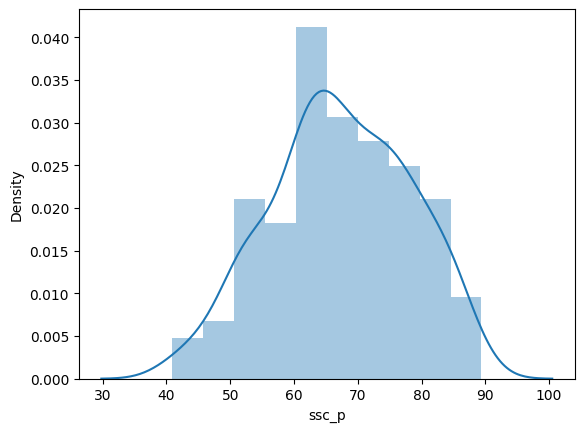

In [21]:
# to view data distribution of "ssc_p"  -- using distplot from seaborn library 
import seaborn as sns
sns.distplot(dataset["ssc_p"])    
""" used to analyse - How the data is distributed in the column"""

<Axes: xlabel='ssc_p', ylabel='Count'>

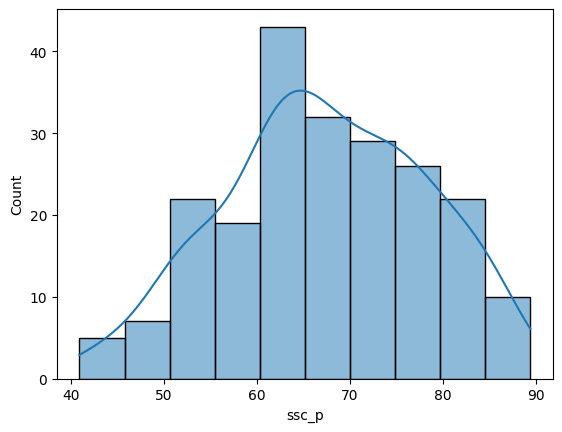

In [22]:
sns.histplot(dataset["ssc_p"], kde=True)        # histogram - frequency graph 

In [39]:
# function to calculate the PDF - propability density function for particular range in the dataset

def get_pdf_propability(dataset_col,startrange,endrange):
    # import libraries
    from matplotlib import pyplot as plt    
    import seaborn as sns
    from scipy.stats import norm 

    # distribution plot 
    axis = sns.distplot(dataset_col,kde=True,kde_kws={'color':'blue'}, color='green')
    plt.axvline(startrange, color='red')
    plt.axvline(endrange, color='red')

    # generate sample - data 
    sample = dataset_col

    # calculate parameters - mean, std dev
    sample_mean = sample.mean()
    sample_stdDev = sample.std()
    print(f"Mean: {sample_mean}, Standard Deviation: {sample_stdDev}")

    # define normal distribution of the data
    dist = norm(sample_mean, sample_stdDev)

    # finding PDF
    values = [ value for value in range(startrange,endrange) ] 
    prob = [dist.pdf(value) for value in values]
    p = sum(prob)
    print(f"PDF for the range of {startrange} to {endrange} is {p}")
    
    
    return p


In [40]:
dataset.columns

Index(['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary', 'gender_M',
       'ssc_b_Others', 'hsc_b_Others', 'hsc_s_Commerce', 'hsc_s_Science',
       'degree_t_Others', 'degree_t_Sci&Tech', 'workex_Yes',
       'specialisation_Mkt&HR', 'status_Placed'],
      dtype='object')

C:\Users\acer\AppData\Local\Temp\ipykernel_13916\3851598567.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  axis = sns.distplot(dataset_col,kde=True,kde_kws={'color':'blue'}, color='green')


Mean: 67.30339534883721, Standard Deviation: 10.827205398231452
PDF for the range of 60 to 80 is 0.6346413295441957


0.6346413295441957

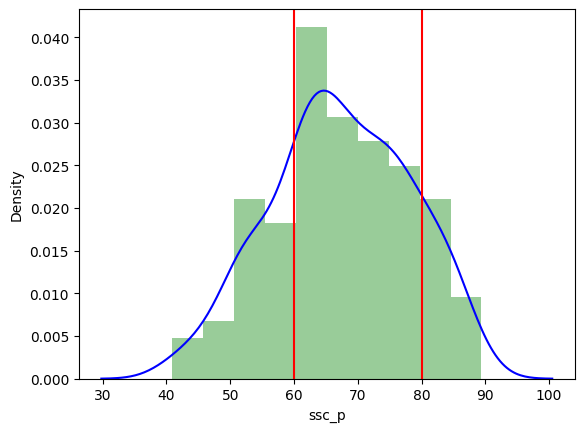

In [41]:
get_pdf_propability(dataset["ssc_p"],60,80)

C:\Users\acer\AppData\Local\Temp\ipykernel_13916\3851598567.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  axis = sns.distplot(dataset_col,kde=True,kde_kws={'color':'blue'}, color='green')


Mean: 67.30339534883721, Standard Deviation: 10.827205398231452
PDF for the range of 40 to 50 is 0.04489259448345172


0.04489259448345172

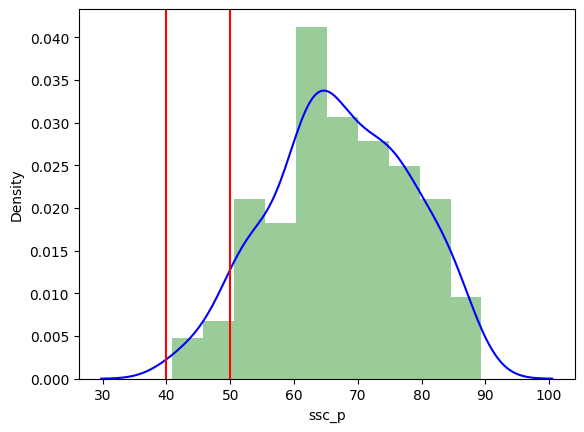

In [35]:
get_pdf_propability(dataset["ssc_p"],40,50)

Mean: 67.30339534883721, Standard Deviation: 10.827205398231452
PDF for the range of 40 to 40 is 0


C:\Users\acer\AppData\Local\Temp\ipykernel_13916\3851598567.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  axis = sns.distplot(dataset_col,kde=True,kde_kws={'color':'blue'}, color='green')


0

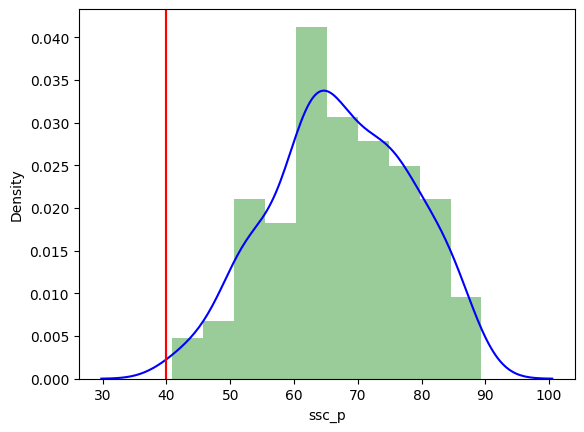

In [36]:
get_pdf_propability(dataset["ssc_p"],40,40)

Mean: 66.33316279069768, Standard Deviation: 10.89750915750298
PDF for the range of 60 to 80 is 0.6213599019595674


C:\Users\acer\AppData\Local\Temp\ipykernel_13916\3851598567.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  axis = sns.distplot(dataset_col,kde=True,kde_kws={'color':'blue'}, color='green')


0.6213599019595674

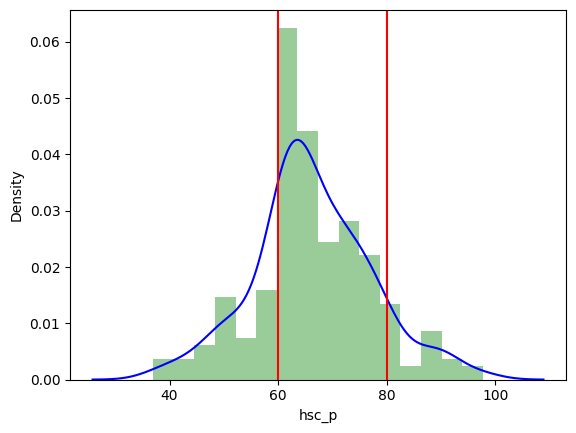

In [32]:
get_pdf_propability(dataset["hsc_p"],60,80)

C:\Users\acer\AppData\Local\Temp\ipykernel_13916\3851598567.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  axis = sns.distplot(dataset_col,kde=True,kde_kws={'color':'blue'}, color='green')


Mean: 66.37018604651163, Standard Deviation: 7.35874328733944
PDF for the range of 60 to 80 is 0.7878523418065079


0.7878523418065079

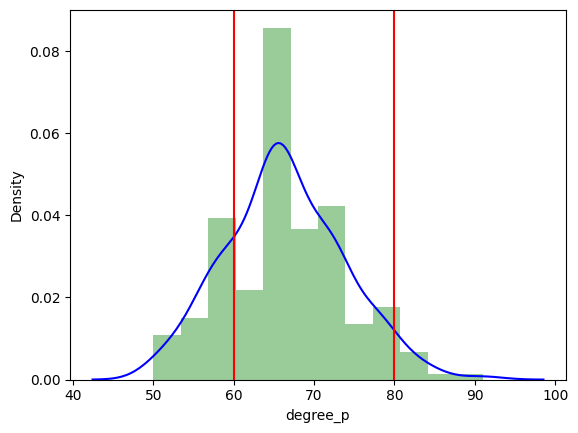

In [42]:
get_pdf_propability(dataset["degree_p"],60,80)

C:\Users\acer\AppData\Local\Temp\ipykernel_13916\3851598567.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  axis = sns.distplot(dataset_col,kde=True,kde_kws={'color':'blue'}, color='green')


Mean: 72.10055813953488, Standard Deviation: 13.275956401653833
PDF for the range of 60 to 80 is 0.5401819748989753


0.5401819748989753

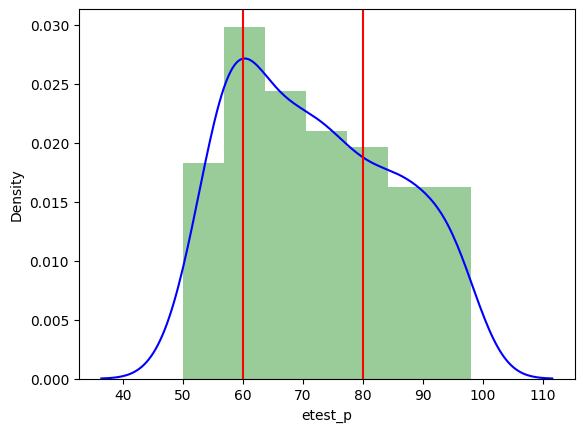

In [43]:
get_pdf_propability(dataset["etest_p"],60,80)

C:\Users\acer\AppData\Local\Temp\ipykernel_13916\3851598567.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  axis = sns.distplot(dataset_col,kde=True,kde_kws={'color':'blue'}, color='green')


Mean: 62.278186046511635, Standard Deviation: 5.833384580683801
PDF for the range of 60 to 80 is 0.681703512728775


0.681703512728775

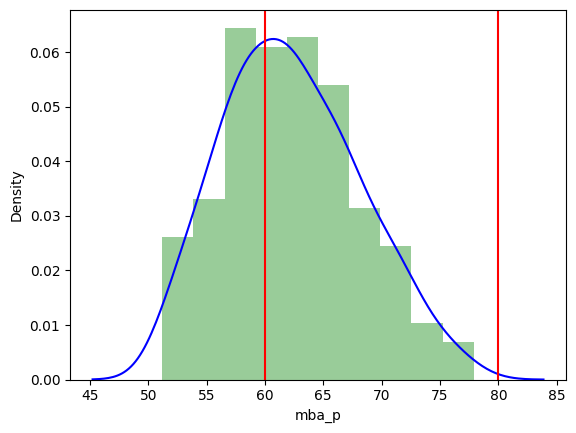

In [44]:
get_pdf_propability(dataset["mba_p"],60,80)

C:\Users\acer\AppData\Local\Temp\ipykernel_13916\3851598567.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  axis = sns.distplot(dataset_col,kde=True,kde_kws={'color':'blue'}, color='green')


Mean: 198702.32558139536, Standard Deviation: 154780.92671560097
PDF for the range of 200000 to 300000 is 0.24024731161501459


0.24024731161501459

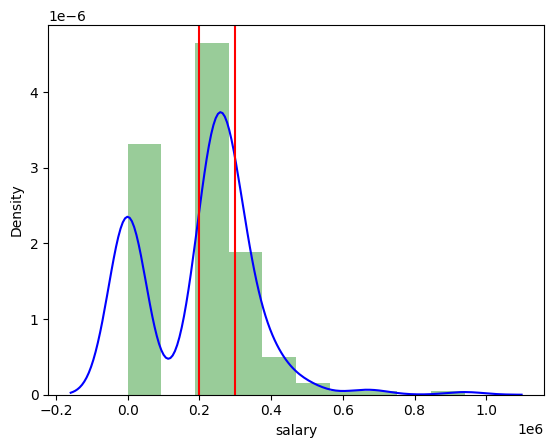

In [48]:
get_pdf_propability(dataset["salary"],200000,300000)

##  PDF workflow

###  distribution plot

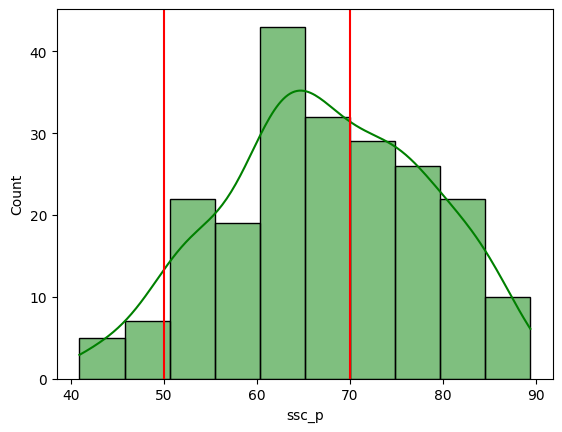

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns     # high level data visualization 

# as distplot is deprecated - we can use hisplot instead of distplot from seaborn
sns.histplot(dataset["ssc_p"],kde=True, line_kws={'color':'blue'},color='green')

plt.axvline(50, color='red')
plt.axvline(70, color='red')

plt.show()

### define normal distribution 

In [95]:
# mean std-dev
mean = dataset["ssc_p"].mean()
std_dev = dataset["ssc_p"].std()

# norm
from scipy.stats import norm  #A normal continuous random variable.
norm_dist = norm(mean,std_dev)
norm_dist


""" creating a frozen distribution object with those parameters: mean, std dev
mean → the center of the distribution
std_dev → the spread (standard deviation)

without frezzing we need to specify repeatedly - using loc, scale
norm.pdf(x, loc=mean, scale=std_dev) 
norm.cdf(x, loc=mean, scale=std_dev)

"""

' creating a frozen distribution object with those parameters: mean, std dev\nmean → the center of the distribution\nstd_dev → the spread (standard deviation)\n\nwithout frezzing we need to specify repeatedly - using loc, scale\nnorm.pdf(x, loc=mean, scale=std_dev) \nnorm.cdf(x, loc=mean, scale=std_dev)\n\n'

### calculating PDF 

In [100]:
values = [ value for value in range(50,70) ]  #values in the range
pdf_values = [norm_dist.pdf(value) for value in values]  #calculate pdf for each values
pdf_values

[0.010275148846718499,
 0.011858764583155554,
 0.013570194930153937,
 0.015396713811418094,
 0.01732069447798158,
 0.019319588759641553,
 0.021366125100358083,
 0.023428741938312646,
 0.025472260251149254,
 0.027458784613159832,
 0.029348806868826963,
 0.031102471650606527,
 0.03268094966902733,
 0.034047854157679046,
 0.03517062909285573,
 0.036021835597530534,
 0.03658026570377481,
 0.03683182040123766,
 0.03677010122906173,
 0.03639668075742896]

In [101]:
prob_sum = (sum(pdf_values))   # calculating the probability changes for area under curve pdf of range 50 - 70 
print("pdf for the range 50 to 70: ", prob_sum)

pdf for the range 50 to 70:  0.5304184324400784
